In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:/users/nandi/python_decal_fa25/course_assignments/homework8/state_data.csv")

In [4]:
print(df.shape)
#there are 52 columns and 4 rows

(52, 4)


In [8]:
print(df.head(5))
print(df.tail(5))

#columns represent state's abbreviation, latitude, longitude, and full name of the state
#the first state is Alaska, and the last is Wyoming
#Why are there more than 50 states?? Idk maybe they counted the District of Columbia?

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


In [11]:
median_latitude = df['latitude'].median()
median_longitude = df['longitude'].median()
print(median_latitude)
print(median_longitude)

39.4355155
-89.093198


In [13]:
df['abs_dist_lat'] = (df['latitude'] - median_latitude).abs()
df['abs_dist_lon'] = (df['longitude'] - median_longitude).abs()

In [17]:
print(df.shape)
#52 rows and 6 columns

(52, 6)


In [23]:
closest_lat = df.sort_values(by='abs_dist_lat', ascending=True).iloc[0]
farthest_lat = df.sort_values(by='abs_dist_lat', ascending=False).iloc[0]
closest_lon = df.sort_values(by='abs_dist_lon', ascending=True).iloc[0]
farthest_lon = df.sort_values(by='abs_dist_lon', ascending=False).iloc[0]
print(f"Closest lat is {closest_lat['name']}, with distance of {closest_lat['abs_dist_lat']:.2f} degrees.")
print(f"Farthest lat is {farthest_lat['name']}, with distance of {farthest_lat['abs_dist_lat']:.2f} degrees.")
print(f"Closest lon is {closest_lon['name']}, with distance of {closest_lon['abs_dist_lon']:.2f} degrees.")
print(f"Farthest lon is {farthest_lon['name']}, with distance of {farthest_lon['abs_dist_lon']:.2f} degrees.")

Closest lat is Colorado, with distance of 0.11 degrees.
Farthest lat is Alaska, with distance of 24.15 degrees.
Closest lon is Illinois, with distance of 0.31 degrees.
Farthest lon is Hawaii, with distance of 66.57 degrees.


In [25]:
!pip install seaborn

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
planets_df = sns.load_dataset('planets')
print(planets_df.head())

            method  number  orbital_period   mass  distance  year
0  Radial Velocity       1         269.300   7.10     77.40  2006
1  Radial Velocity       1         874.774   2.21     56.95  2008
2  Radial Velocity       1         763.000   2.60     19.84  2011
3  Radial Velocity       1         326.030  19.40    110.62  2007
4  Radial Velocity       1         516.220  10.50    119.47  2009


In [32]:
planets_df = planets_df.dropna(axis=1)

In [34]:
print(planets_df.shape)
print(planets_df.head())
print(planets_df.tail())
#there are 1035 rows and 3 columns
#the columns are method of detection of the exoplanet, number of planets that system has, and the year it was detected
#(I think?)

(1035, 3)
            method  number  year
0  Radial Velocity       1  2006
1  Radial Velocity       1  2008
2  Radial Velocity       1  2011
3  Radial Velocity       1  2007
4  Radial Velocity       1  2009
       method  number  year
1030  Transit       1  2006
1031  Transit       1  2007
1032  Transit       1  2007
1033  Transit       1  2008
1034  Transit       1  2008


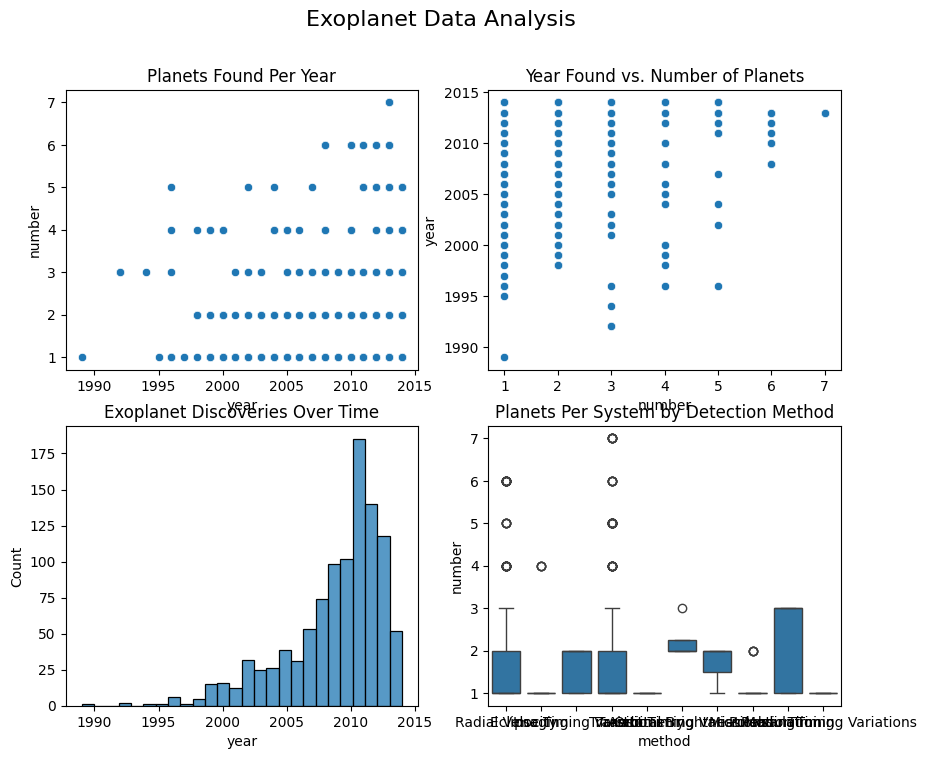

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plt.suptitle('Exoplanet Data Analysis', fontsize=16)

#Top left - scatter plot year vs. number
sns.scatterplot(x='year', y='number', data=planets_df, ax=axes[0, 0])
axes[0, 0].set_title('Planets Found Per Year')

#Top right - scatter plot number vs. year (switch axes)
sns.scatterplot(x='number', y='year', data=planets_df, ax=axes[0, 1])
axes[0, 1].set_title('Year Found vs. Number of Planets')

#bottom left - histogram
sns.histplot(data=planets_df, x='year', ax=axes[1, 0])
axes[1, 0].set_title('Exoplanet Discoveries Over Time')

#bottom right - categorical plot (method of detection vs. number)
sns.boxplot(x='method', y='number', data=planets_df, ax=axes[1, 1])
axes[1, 1].set_title('Planets Per System by Detection Method')
#why does this look weird

plt.show()

The first and second plot are essentially the same thing with different orientations. They didn't scale very well because the values are discrete, not continuous. The third plot worked better; it showed the count of exoplanet discoveries per year, and shows an increasing trend as time went on. The last plot is also somewhat indecipherable because the data types didn't seem to work well with it (or I just did it wrong, maybe more likely), but in principle I guess it could have shown which kind of detection methods had a greater effectiveness.